# 2023, 300 m — pooled correlation with two Jordi masks

Jordi's crop-type map was built for **2023**, so this is the one year where the mask is
not anachronistic. Peak GCVI re-exported for 2023 at **300 m** (previously 500 m) under
four conditions:

| type | GCVI averaged over |
|---|---|
| `raw_300m` | all pixels |
| `esri_300m` | ESRI LULC cropland (class 5) |
| `jordi_300m` | Jordi rice class — **single model** for all of India |
| `jordi_300m_20models` | Jordi rice class — **20 regional models** |

**Pooled r** here = Pearson over the districts of one state **in 2023 only**, so
n = number of districts (not district-years). A state's r is therefore much noisier
than in the 12-year analysis.

**Empty masks:** districts with no retained pixels get `gcvi_mean = 0` and keep their
real yield (the KEEP handling, as in the main notebooks). No rows dropped.

**Coverage:** every state with a `*_raw_300m.tif` on disk is picked up automatically.
As of this run, West Bengal has no 300 m export. Chandigarh (1 district) and
Puducherry (3) enter the table but have too few districts for a correlation.

**n per state = number of districts** with both a 2023 yield and a GCVI value — one
year, so there is no time dimension in n.

In [1]:
import os, re, glob, warnings
import numpy as np, pandas as pd, nbformat
import geopandas as gpd, rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'legend.title_fontsize': 13, 'figure.titlesize': 20,
})

ROOT = '../..'
OUT  = f'{ROOT}/outputs'
YEAR = 2023
TYPES = ['raw_300m', 'esri_300m', 'jordi_300m', 'jordi_300m_20models']
LABEL = {'raw_300m': 'raw', 'esri_300m': 'ESRI cropland',
         'jordi_300m': 'Jordi, 1 model', 'jordi_300m_20models': 'Jordi, 20 models'}

_nb  = nbformat.read(f'{ROOT}/notebooks/02_mask_analysis/gsv_preds_exploration.ipynb', as_version=4)
_src = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
_src = _src.replace("os.makedirs('outputs', exist_ok=True)", "").replace("'../../data/", f"'{ROOT}/data/")
CFG = {}; exec(_src, CFG)
REGIONS, REGION_LABELS, load_yield = CFG['REGIONS'], CFG['REGION_LABELS'], CFG['load_yield']

# GEE exports West Bengal as 'west_bengal'; everything local uses 'wb'
FILE_KEY = {}                                   # region_key -> key used in the filename
for f in glob.glob(f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_*_raw_300m.tif'):
    fk = re.search(rf'{YEAR}_(.+)_raw_300m\.tif', f).group(1)
    FILE_KEY[{'west_bengal': 'wb'}.get(fk, fk)] = fk
STATES = sorted(k for k in FILE_KEY if k in REGIONS)
_missing = sorted(set(REGIONS) - set(STATES))
print(f"{len(STATES)} states with 300 m exports: {', '.join(STATES)}")
print(f"no 300 m export: {', '.join(_missing)}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
27 states with 300 m exports: andhra_pradesh, assam, bihar, chandigarh, chhattisgarh, gujarat, haryana, himachal_pradesh, jharkhand, karnataka, kerala, maharashtra, manipur, meghalaya, mizoram, mp, nagaland, odisha, puducherry, punjab, rajasthan, tamil_nadu, telangana, tripura, up, uttarakhand, wb
no 300 m export: andaman_nicobar, dadra_nagar_haveli, goa


In [2]:
def district_means(k, t):
    """Mean peak GCVI per district for one state and one 300 m type (KEEP: empty -> 0)."""
    tif = f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{FILE_KEY[k]}_{t}.tif'
    g = gpd.read_file(REGIONS[k]['shp']).to_crs('EPSG:4326')
    g['district'] = g['gaul2_name'].str.strip().str.title().str.replace(r'\s+', ' ', regex=True)
    with rasterio.open(tif) as s:
        a = s.read(1).astype('float32'); nd = s.nodata; aff = s.transform
    a[~np.isfinite(a)] = np.nan
    if nd is not None:
        a[a == nd] = np.nan
    st = zonal_stats(g, a, affine=aff, stats=['mean', 'count'], nodata=np.nan)
    return pd.DataFrame({'district': g['district'],
                         'gcvi_mean': [s['mean'] for s in st],
                         'n_px': [s['count'] for s in st]})


rows = []
for k in STATES:
    y = load_yield(REGIONS[k]['state_name'])
    y = y[y.year == YEAR][['district', 'yield_kg_ha']]
    for t in TYPES:
        d = district_means(k, t)
        d['gcvi_mean'] = d['gcvi_mean'].fillna(0)            # KEEP handling
        d = d.groupby('district', as_index=False).agg(gcvi_mean=('gcvi_mean', 'mean'),
                                                      n_px=('n_px', 'sum'))
        d['region_key'], d['type'] = k, t
        rows.append(d.merge(y, on='district', how='inner'))
    print(f"  {k:<18} done", flush=True)

PANEL = pd.concat(rows, ignore_index=True)
PANEL.to_csv(f'{OUT}/gcvi_2023_300m_district_panel.csv', index=False)
print(f"\n{len(PANEL):,} district x type rows")

  andhra_pradesh     done


  assam              done


  bihar              done


  chandigarh         done


  chhattisgarh       done


...

  tripura            done


  up                 done


  uttarakhand        done


  wb                 done



2,384 district x type rows


In [3]:
def pear(d):
    if len(d) < 4 or d.gcvi_mean.nunique() < 2 or d.yield_kg_ha.nunique() < 2:
        return np.nan, np.nan
    r = stats.pearsonr(d.gcvi_mean, d.yield_kg_ha)
    return r.statistic, r.pvalue

out = []
for k in STATES:
    rec = {'region_key': k, 'state': REGION_LABELS.get(k, k)}
    for t in TYPES:
        d = PANEL[(PANEL.region_key == k) & (PANEL.type == t)]
        r, p = pear(d)
        rec[f'r_{t}'], rec[f'p_{t}'] = r, p
        rec['n_districts'] = len(d)
        if t != 'raw_300m':
            rec[f'empty_{t}'] = int((d.n_px == 0).sum())
    out.append(rec)
T = pd.DataFrame(out)
for t in TYPES[1:]:
    T[f'd_{t}'] = T[f'r_{t}'] - T['r_raw_300m']
T['d_20_vs_1'] = T['r_jordi_300m_20models'] - T['r_jordi_300m']
T.to_csv(f'{OUT}/gcvi_2023_300m_correlation.csv', index=False)

def star(p):
    """*** p<0.001, ** p<0.01, * p<0.05, . p<0.10, blank otherwise."""
    if not np.isfinite(p):
        return ''
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else '.' if p < .10 else ''


def rp(r, p):
    return f"{r:+.3f}{star(p):<3}" if np.isfinite(r) else f"{'--':>6}   "


print("per-state r, 2023 @ 300 m   (*** p<.001  ** p<.01  * p<.05  . p<.10)")
print("p is the two-sided test that the state's r differs from 0, df = n_districts - 2\n")
print(f"{'state':<17}{'n':>3}  {'raw':^10}{'ESRI':^10}{'Jordi-1':^10}{'Jordi-20':^10}"
      f"{'d_j1':>8}{'d_j20':>8}{'j20-j1':>8}")
print('-' * 94)
for _, r in T.sort_values('d_jordi_300m_20models', ascending=False).iterrows():
    print(f"{r.state:<17}{int(r.n_districts):>3}  "
          + ''.join(rp(r[f'r_{t}'], r[f'p_{t}']) for t in TYPES)
          + (f"{r.d_jordi_300m:>8.3f}{r.d_jordi_300m_20models:>8.3f}{r.d_20_vs_1:>8.3f}"
             if np.isfinite(r.d_jordi_300m) else f"{'--':>8}{'--':>8}{'--':>8}"))

print("\nstates with p < 0.05, by condition:")
for t in TYPES:
    sig = T.loc[T[f'p_{t}'] < .05, 'state'].tolist()
    print(f"  {LABEL[t]:<18} {len(sig):>2}/{T[f'p_{t}'].notna().sum()}   {', '.join(sig)}")

# Bonferroni across all 25 states x 4 conditions
flat = T.melt(id_vars='state', value_vars=[f'p_{t}' for t in TYPES],
              var_name='cond', value_name='p').dropna()
flat['cond'] = flat.cond.str.replace('p_', '', regex=False).map(LABEL)
m = len(flat)
alpha_bonf = 0.05 / m
flat['p_adj'] = (flat.p * m).clip(upper=1.0)          # equivalently, adjusted p
flat['bonf_sig'] = flat.p <= alpha_bonf
flat = flat.sort_values('p').reset_index(drop=True)

print(f"\nBonferroni, family-wise alpha 0.05 across all {m} state x condition tests")
print(f"  per-test threshold = 0.05/{m} = {alpha_bonf:.6f}")
print(f"  {int(flat.bonf_sig.sum())} of {m} survive\n")
print(flat[flat.bonf_sig][['state', 'cond', 'p', 'p_adj']].round(6).to_string(index=False))

print("\nsurviving Bonferroni, by condition:")
for t in TYPES:
    s = flat[(flat.cond == LABEL[t]) & flat.bonf_sig]['state'].tolist()
    print(f"  {LABEL[t]:<18} {len(s):>2}   {', '.join(s) if s else '--'}")

print(f"\nfor reference, uncorrected p<0.05 gives {int((flat.p < 0.05).sum())} of {m}")
flat.to_csv(f'{OUT}/gcvi_2023_300m_significance.csv', index=False)

per-state r, 2023 @ 300 m   (*** p<.001  ** p<.01  * p<.05  . p<.10)
p is the two-sided test that the state's r differs from 0, df = n_districts - 2

state              n     raw       ESRI    Jordi-1   Jordi-20     d_j1   d_j20  j20-j1
----------------------------------------------------------------------------------------------
Tripura            8  -0.921** +0.503   +0.445   +0.331      1.366   1.252  -0.114
Nagaland          11  -0.794** +0.089   +0.302   +0.344      1.095   1.138   0.042
West Bengal       22  -0.354   +0.137   +0.548** +0.425*     0.902   0.778  -0.123
Rajasthan         21  -0.432.  -0.293   +0.039   +0.247      0.471   0.678   0.207
Karnataka         29  -0.254   -0.168   +0.368*  +0.421*     0.622   0.675   0.053
Kerala            13  -0.396   -0.382   -0.240   +0.274      0.156   0.670   0.514
Himachal Pradesh  11  -0.141   -0.608*  +0.478   +0.501      0.619   0.642   0.023
Telangana         32  -0.009   +0.352*  +0.473** +0.515**    0.482   0.525   0.043
Mizo

In [4]:
def ttest(v):
    v = v.dropna(); n = len(v)
    if n < 3:
        return dict(n=n)
    t, p = stats.ttest_1samp(v, 0)
    ci = stats.t.interval(0.95, n-1, loc=v.mean(), scale=v.std(ddof=1)/np.sqrt(n))
    w = stats.wilcoxon(v).pvalue
    return dict(n=n, mean=v.mean(), median=v.median(), pos=100*(v > 0).mean(),
                t=t, p=p, lo=ci[0], hi=ci[1], p_wilcoxon=w)

S = pd.DataFrame({
    'ESRI − raw':            ttest(T['d_esri_300m']),
    'Jordi 1-model − raw':   ttest(T['d_jordi_300m']),
    'Jordi 20-models − raw': ttest(T['d_jordi_300m_20models']),
    'Jordi 20 − Jordi 1':    ttest(T['d_20_vs_1']),
}).T
S.to_csv(f'{OUT}/gcvi_2023_300m_summary.csv')
print("one-sample t-test on the per-state delta r, against 0\n")
print(S.round(4).to_string())

print("\nmean r across states (not a test, for orientation):")
for t in TYPES:
    print(f"  {LABEL[t]:<18} mean r = {T[f'r_{t}'].mean():+.3f}   "
          f"significant (p<0.05) in {(T[f'p_{t}'] < 0.05).sum()}/{T[f'r_{t}'].notna().sum()} states")

one-sample t-test on the per-state delta r, against 0

                          n    mean  median   pos       t       p      lo      hi  p_wilcoxon
ESRI − raw             25.0  0.1579  0.0673  68.0  1.8973  0.0699 -0.0139  0.3297      0.0851
Jordi 1-model − raw    25.0  0.3271  0.2792  88.0  3.9647  0.0006  0.1568  0.4974      0.0001
Jordi 20-models − raw  25.0  0.2939  0.2847  84.0  2.9389  0.0072  0.0875  0.5003      0.0012
Jordi 20 − Jordi 1     25.0 -0.0332  0.0001  52.0 -0.6456  0.5247 -0.1393  0.0729      0.6915

mean r across states (not a test, for orientation):
  raw                mean r = -0.045   significant (p<0.05) in 7/25 states
  ESRI cropland      mean r = +0.113   significant (p<0.05) in 7/25 states
  Jordi, 1 model     mean r = +0.282   significant (p<0.05) in 10/25 states
  Jordi, 20 models   mean r = +0.249   significant (p<0.05) in 8/25 states


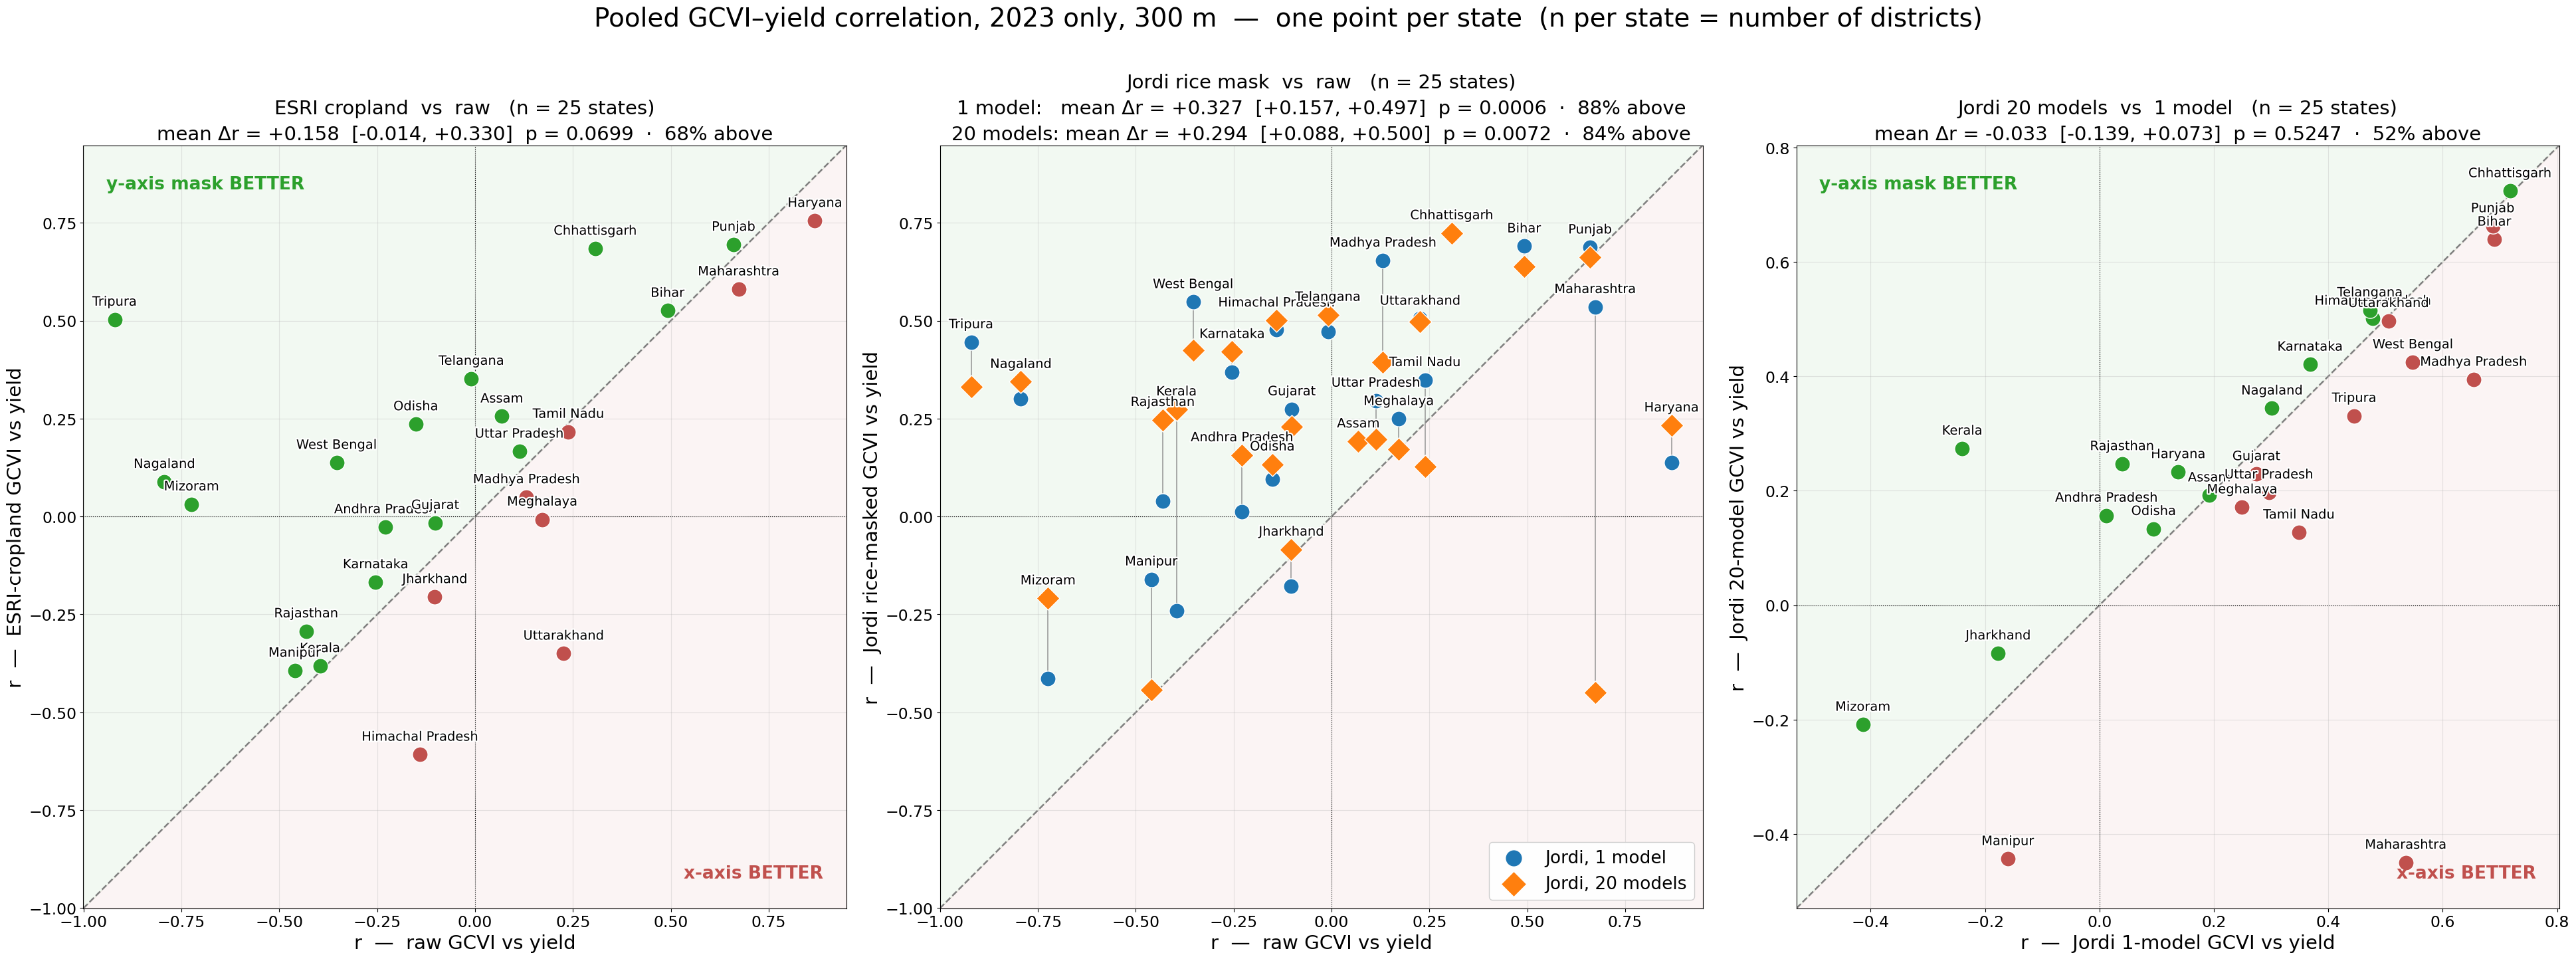

In [5]:
def frame(ax, xs, ys):
    lo = min(min(v.min() for v in xs), min(v.min() for v in ys)) - 0.08
    hi = max(max(v.max() for v in xs), max(v.max() for v in ys)) + 0.08
    ax.fill_between([lo, hi], [lo, hi], hi, color='#2ca02c', alpha=0.06, zorder=0)
    ax.fill_between([lo, hi], lo, [lo, hi], color='#c0504d', alpha=0.06, zorder=0)
    ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1.8, zorder=1)
    ax.axhline(0, color='black', lw=0.8, ls=':'); ax.axvline(0, color='black', lw=0.8, ls=':')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.tick_params(labelsize=17); ax.grid(alpha=0.3)


def name_points(ax, d, xc, yc):
    for _, r in d.iterrows():
        ax.annotate(r['state'], (r[xc], r[yc]), fontsize=14,
                    textcoords='offset points', xytext=(0, 15), ha='center', zorder=5,
                    path_effects=[pe.withStroke(linewidth=3.2, foreground='white')])


def stat_line(v, tag=''):
    s = ttest(v)
    return (f"{tag}mean Δr = {s['mean']:+.3f}  [{s['lo']:+.3f}, {s['hi']:+.3f}]  "
            f"p = {s['p']:.4f}  ·  {s['pos']:.0f}% above")


fig, axes = plt.subplots(1, 3, figsize=(39, 14.5))

# ── 1. ESRI vs raw ───────────────────────────────────────────────────────
ax = axes[0]
d = T[['state', 'r_raw_300m', 'r_esri_300m']].dropna()
frame(ax, [d.r_raw_300m], [d.r_esri_300m])
up = d.r_esri_300m > d.r_raw_300m
ax.scatter(d.r_raw_300m[up],  d.r_esri_300m[up],  s=280, color='#2ca02c', ec='white', lw=1, zorder=3)
ax.scatter(d.r_raw_300m[~up], d.r_esri_300m[~up], s=280, color='#c0504d', ec='white', lw=1, zorder=3)
name_points(ax, d, 'r_raw_300m', 'r_esri_300m')
ax.set_xlabel('r  —  raw GCVI vs yield', fontsize=21)
ax.set_ylabel('r  —  ESRI-cropland GCVI vs yield', fontsize=21)
ax.set_title(f"ESRI cropland  vs  raw   (n = {len(d)} states)\n"
             f"{stat_line(d.r_esri_300m - d.r_raw_300m)}", fontsize=21, linespacing=1.5)

# ── 2. both Jordi masks vs raw, one panel ────────────────────────────────
ax = axes[1]
d = T[['state', 'r_raw_300m', 'r_jordi_300m', 'r_jordi_300m_20models']].dropna()
frame(ax, [d.r_raw_300m], [d.r_jordi_300m, d.r_jordi_300m_20models])
for _, r in d.iterrows():                          # link each state's two masks
    ax.plot([r.r_raw_300m, r.r_raw_300m], [r.r_jordi_300m, r.r_jordi_300m_20models],
            color='#888', lw=1.4, alpha=0.7, zorder=2)
ax.scatter(d.r_raw_300m, d.r_jordi_300m, s=280, marker='o', color='#1f77b4',
           ec='white', lw=1, zorder=3, label='Jordi, 1 model')
ax.scatter(d.r_raw_300m, d.r_jordi_300m_20models, s=320, marker='D', color='#ff7f0e',
           ec='white', lw=1, zorder=4, label='Jordi, 20 models')
d['_y'] = d[['r_jordi_300m', 'r_jordi_300m_20models']].max(axis=1)   # label above the higher
name_points(ax, d, 'r_raw_300m', '_y')
ax.legend(loc='lower right', fontsize=19, markerscale=1.1, framealpha=0.95)
ax.set_xlabel('r  —  raw GCVI vs yield', fontsize=21)
ax.set_ylabel('r  —  Jordi rice-masked GCVI vs yield', fontsize=21)
ax.set_title(f"Jordi rice mask  vs  raw   (n = {len(d)} states)\n"
             f"{stat_line(d.r_jordi_300m - d.r_raw_300m, '1 model:   ')}\n"
             f"{stat_line(d.r_jordi_300m_20models - d.r_raw_300m, '20 models: ')}",
             fontsize=21, linespacing=1.5)

# ── 3. 20 models vs 1 model ──────────────────────────────────────────────
ax = axes[2]
d = T[['state', 'r_jordi_300m', 'r_jordi_300m_20models']].dropna()
frame(ax, [d.r_jordi_300m], [d.r_jordi_300m_20models])
up = d.r_jordi_300m_20models > d.r_jordi_300m
ax.scatter(d.r_jordi_300m[up],  d.r_jordi_300m_20models[up],  s=280, color='#2ca02c', ec='white', lw=1, zorder=3)
ax.scatter(d.r_jordi_300m[~up], d.r_jordi_300m_20models[~up], s=280, color='#c0504d', ec='white', lw=1, zorder=3)
name_points(ax, d, 'r_jordi_300m', 'r_jordi_300m_20models')
ax.set_xlabel('r  —  Jordi 1-model GCVI vs yield', fontsize=21)
ax.set_ylabel('r  —  Jordi 20-model GCVI vs yield', fontsize=21)
ax.set_title(f"Jordi 20 models  vs  1 model   (n = {len(d)} states)\n"
             f"{stat_line(d.r_jordi_300m_20models - d.r_jordi_300m)}",
             fontsize=21, linespacing=1.5)

for ax in (axes[0], axes[2]):
    ax.text(0.03, 0.96, 'y-axis mask BETTER', transform=ax.transAxes, va='top',
            fontsize=19, color='#2ca02c', fontweight='bold')
    ax.text(0.97, 0.04, 'x-axis BETTER', transform=ax.transAxes, ha='right',
            fontsize=19, color='#c0504d', fontweight='bold')

fig.suptitle(f'Pooled GCVI–yield correlation, {YEAR} only, 300 m  —  one point per state  '
             '(n per state = number of districts)', y=1.02, fontsize=28)
plt.tight_layout()
plt.savefig(f'{OUT}/gcvi_2023_300m_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

## Same test at 500 m

The 2023 values at the original **500 m** resolution come from
`data/processed/gcvi_district_cache.csv`. That cache was built on 2026-09-09, *before*
the 300 m download overwrote the 2023 `_raw/_esri/_jordi.tif` files for 22 states, so it
still holds the true 500 m district means.

The 500 m run has **three** conditions, not four. Its Jordi mask came from the
`india_crop_states_grid_2km_n3_20models` asset, so it is the **20-model** mask (MP and
Punjab label it `crop`). There is no 500 m single-model export.

Same setup as above: 2023 only, one Pearson per state across its districts, KEEP
handling (the cache already stores empty masks as `gcvi_mean = 0`), n ≥ 4 districts.

In [6]:
C500 = pd.read_csv(f'{ROOT}/data/processed/gcvi_district_cache.csv')
C500 = C500[C500.year == YEAR].copy()
C500['mask'] = C500['mask'].replace({'crop': 'jordi'})       # MP/Punjab naming
T500_TYPES = {'raw': 'raw', 'esri': 'ESRI cropland', 'jordi': 'Jordi, 20 models'}

out = []
for k in STATES:
    y = load_yield(REGIONS[k]['state_name'])
    y = y[y.year == YEAR][['district', 'yield_kg_ha']]
    rec = {'region_key': k, 'state': REGION_LABELS.get(k, k)}
    for m in T500_TYPES:
        d = C500[(C500.region_key == k) & (C500['mask'] == m)][['district', 'gcvi_mean']]
        d = d.merge(y, on='district', how='inner')
        r, pv = pear(d)
        rec[f'r_{m}'], rec[f'p_{m}'], rec['n_districts'] = r, pv, len(d)
    out.append(rec)
T500 = pd.DataFrame(out)
T500['d_esri']  = T500.r_esri  - T500.r_raw
T500['d_jordi'] = T500.r_jordi - T500.r_raw
T500.to_csv(f'{OUT}/gcvi_2023_500m_correlation.csv', index=False)

print("500 m, 2023 only — per state\n")
print(T500[['state', 'n_districts', 'r_raw', 'r_esri', 'r_jordi', 'd_esri', 'd_jordi']]
      .sort_values('d_jordi', ascending=False).round(3).to_string(index=False))

S500 = pd.DataFrame({'ESRI − raw': ttest(T500.d_esri),
                     'Jordi 20-models − raw': ttest(T500.d_jordi)}).T
S500.to_csv(f'{OUT}/gcvi_2023_500m_summary.csv')
print("\n500 m — one-sample t-test on per-state Δr\n")
print(S500.round(4).to_string())

500 m, 2023 only — per state

           state  n_districts  r_raw  r_esri  r_jordi  d_esri  d_jordi
         Tripura            8 -0.960   0.458   -0.027   1.418    0.933
        Nagaland           11 -0.539   0.099    0.392   0.638    0.931
Himachal Pradesh           11 -0.295  -0.299    0.514  -0.004    0.809
       Rajasthan           21 -0.439  -0.294    0.318   0.145    0.757
         Mizoram            8 -0.629   0.064    0.119   0.693    0.748
          Kerala           13 -0.490  -0.489    0.242   0.001    0.732
         Manipur            4 -0.252   0.339    0.428   0.591    0.680
       Karnataka           29 -0.239  -0.168    0.372   0.071    0.611
     West Bengal           22 -0.377   0.243    0.172   0.620    0.549
       Telangana           32 -0.058   0.305    0.468   0.363    0.525
  Madhya Pradesh           49  0.119   0.052    0.617  -0.067    0.498
    Chhattisgarh           26  0.276   0.665    0.709   0.389    0.434
  Andhra Pradesh           13 -0.210  -0.018   

In [7]:
# ── 500 m vs 300 m, side by side ─────────────────────────────────────────
CMP = T500[['region_key', 'state', 'n_districts', 'r_raw', 'r_esri', 'r_jordi']].merge(
      T[['region_key', 'r_raw_300m', 'r_esri_300m', 'r_jordi_300m_20models']],
      on='region_key')
CMP.columns = ['region_key', 'state', 'n', 'raw_500', 'esri_500', 'jordi20_500',
               'raw_300', 'esri_300', 'jordi20_300']
CMP['d_jordi20_500'] = CMP.jordi20_500 - CMP.raw_500
CMP['d_jordi20_300'] = CMP.jordi20_300 - CMP.raw_300
CMP.to_csv(f'{OUT}/gcvi_2023_500m_vs_300m.csv', index=False)

print("r by resolution, same 2023 districts\n")
print(CMP.drop(columns='region_key').sort_values('d_jordi20_300', ascending=False)
         .round(3).to_string(index=False))

print("\nhow much does resolution move r?  (300 m minus 500 m, per state)")
for a, b, lab in [('raw_300', 'raw_500', 'raw'), ('esri_300', 'esri_500', 'ESRI'),
                  ('jordi20_300', 'jordi20_500', 'Jordi 20-models')]:
    v = (CMP[a] - CMP[b]).dropna()
    t_, p_ = stats.ttest_1samp(v, 0)
    rr = stats.pearsonr(CMP[[a, b]].dropna()[a], CMP[[a, b]].dropna()[b]).statistic
    print(f"  {lab:<16} mean shift {v.mean():+.3f}   mean |shift| {v.abs().mean():.3f}   "
          f"p={p_:.3f}   r(500,300) = {rr:+.3f}")

r by resolution, same 2023 districts

           state  n  raw_500  esri_500  jordi20_500  raw_300  esri_300  jordi20_300  d_jordi20_500  d_jordi20_300
         Tripura  8   -0.960     0.458       -0.027   -0.921     0.503        0.331          0.933          1.252
        Nagaland 11   -0.539     0.099        0.392   -0.794     0.089        0.344          0.931          1.138
     West Bengal 22   -0.377     0.243        0.172   -0.354     0.137        0.425          0.549          0.778
       Rajasthan 21   -0.439    -0.294        0.318   -0.432    -0.293        0.247          0.757          0.678
       Karnataka 29   -0.239    -0.168        0.372   -0.254    -0.168        0.421          0.611          0.675
          Kerala 13   -0.490    -0.489        0.242   -0.396    -0.382        0.274          0.732          0.670
Himachal Pradesh 11   -0.295    -0.299        0.514   -0.141    -0.608        0.501          0.809          0.642
       Telangana 32   -0.058     0.305        0.46

## Signed R²

`signed R² = sign(r) · r²` — the share of yield variance GCVI explains, carrying the
direction of the relationship. Plain r² would drop the sign, and 14 of 25 states have a
negative raw r at 300 m (16 at 500 m).

Per-state p-values are the same as for r (a simple regression's R² test is the r test).
The t-tests below are on per-state **Δ signed R²** against 0.

In [8]:
def sr2(r):
    return np.sign(r) * r**2

# ── 300 m ────────────────────────────────────────────────────────────────
for t in TYPES:
    T[f'sR2_{t}'] = sr2(T[f'r_{t}'])
for t in TYPES[1:]:
    T[f'dsR2_{t}'] = T[f'sR2_{t}'] - T['sR2_raw_300m']
T['dsR2_20_vs_1'] = T['sR2_jordi_300m_20models'] - T['sR2_jordi_300m']

# ── 500 m ────────────────────────────────────────────────────────────────
for m in ['raw', 'esri', 'jordi']:
    T500[f'sR2_{m}'] = sr2(T500[f'r_{m}'])
T500['dsR2_esri']  = T500.sR2_esri  - T500.sR2_raw
T500['dsR2_jordi'] = T500.sR2_jordi - T500.sR2_raw

SR = pd.DataFrame({
    '300m  ESRI − raw':            ttest(T['dsR2_esri_300m']),
    '300m  Jordi 1-model − raw':   ttest(T['dsR2_jordi_300m']),
    '300m  Jordi 20-models − raw': ttest(T['dsR2_jordi_300m_20models']),
    '300m  Jordi 20 − Jordi 1':    ttest(T['dsR2_20_vs_1']),
    '500m  ESRI − raw':            ttest(T500['dsR2_esri']),
    '500m  Jordi 20-models − raw': ttest(T500['dsR2_jordi']),
}).T
SR.to_csv(f'{OUT}/gcvi_2023_signedR2_summary.csv')
print("one-sample t-test on per-state Δ signed R², against 0\n")
print(SR.round(4).to_string())

print("\nmean signed R² per condition")
print("  300m: " + "  ".join(f"{LABEL[t]} {T[f'sR2_{t}'].mean():+.3f}" for t in TYPES))
print("  500m: " + "  ".join(f"{T500_TYPES[m]} {T500[f'sR2_{m}'].mean():+.3f}"
                             for m in ['raw', 'esri', 'jordi']))

SRT = T[['state', 'n_districts'] + [f'sR2_{t}' for t in TYPES] +
        ['dsR2_jordi_300m', 'dsR2_jordi_300m_20models', 'dsR2_20_vs_1']].merge(
      T500[['state', 'sR2_raw', 'sR2_esri', 'sR2_jordi', 'dsR2_jordi']]
      .rename(columns={'sR2_raw': 'sR2_raw_500m', 'sR2_esri': 'sR2_esri_500m',
                       'sR2_jordi': 'sR2_jordi20_500m', 'dsR2_jordi': 'dsR2_jordi20_500m'}),
      on='state')
SRT.to_csv(f'{OUT}/gcvi_2023_signedR2_correlation.csv', index=False)
print("\nper-state signed R², 2023   (stars = the state's own r test, same p as for r)")
print("  300 m: raw / ESRI / Jordi-1 / Jordi-20      500 m: raw / ESRI / Jordi-20\n")
print(f"{'state':<17}{'n':>3}  {'raw':^10}{'ESRI':^10}{'Jordi-1':^10}{'Jordi-20':^10}"
      f"{'d_j1':>8}{'d_j20':>8} | {'raw500':^10}{'j20_500':^10}{'d500':>8}")
print('-' * 122)
M = T.merge(T500[['state', 'r_raw', 'p_raw', 'r_jordi', 'p_jordi']], on='state', how='left')
for _, r in M.sort_values('dsR2_jordi_300m_20models', ascending=False).iterrows():
    line = f"{r.state:<17}{int(r.n_districts):>3}  "
    line += ''.join(rp(sr2(r[f'r_{t}']), r[f'p_{t}']) for t in TYPES)
    line += (f"{r.dsR2_jordi_300m:>8.3f}{r.dsR2_jordi_300m_20models:>8.3f} | "
             if np.isfinite(r.dsR2_jordi_300m) else f"{'--':>8}{'--':>8} | ")
    line += rp(sr2(r.r_raw), r.p_raw) + rp(sr2(r.r_jordi), r.p_jordi)
    d500 = sr2(r.r_jordi) - sr2(r.r_raw)
    line += f"{d500:>8.3f}" if np.isfinite(d500) else f"{'--':>8}"
    print(line)

print("\nstates with p < 0.05 (500 m), by condition:")
for m_, lab in T500_TYPES.items():
    sig = T500.loc[T500[f'p_{m_}'] < .05, 'state'].tolist()
    print(f"  {lab:<18} {len(sig):>2}/{T500[f'p_{m_}'].notna().sum()}   {', '.join(sig)}")

one-sample t-test on per-state Δ signed R², against 0

                                n    mean  median   pos       t       p      lo      hi  p_wilcoxon
300m  ESRI − raw             25.0  0.1000  0.0366  68.0  1.7096  0.1002 -0.0207  0.2207      0.0667
300m  Jordi 1-model − raw    25.0  0.1780  0.1865  88.0  2.8183  0.0095  0.0476  0.3083      0.0003
300m  Jordi 20-models − raw  25.0  0.1417  0.1382  84.0  2.0682  0.0496  0.0003  0.2832      0.0025
300m  Jordi 20 − Jordi 1     25.0 -0.0362  0.0000  52.0 -1.4082  0.1719 -0.0893  0.0169      0.4742
500m  ESRI − raw             25.0  0.1020  0.0295  72.0  1.9488  0.0631 -0.0060  0.2100      0.0187
500m  Jordi 20-models − raw  25.0  0.1486  0.1716  80.0  2.4346  0.0227  0.0226  0.2746      0.0031

mean signed R² per condition
  300m: raw -0.029  ESRI cropland +0.071  Jordi, 1 model +0.149  Jordi, 20 models +0.113
  500m: raw -0.015  ESRI cropland +0.087  Jordi, 20 models +0.134

per-state signed R², 2023   (stars = the state's own r test

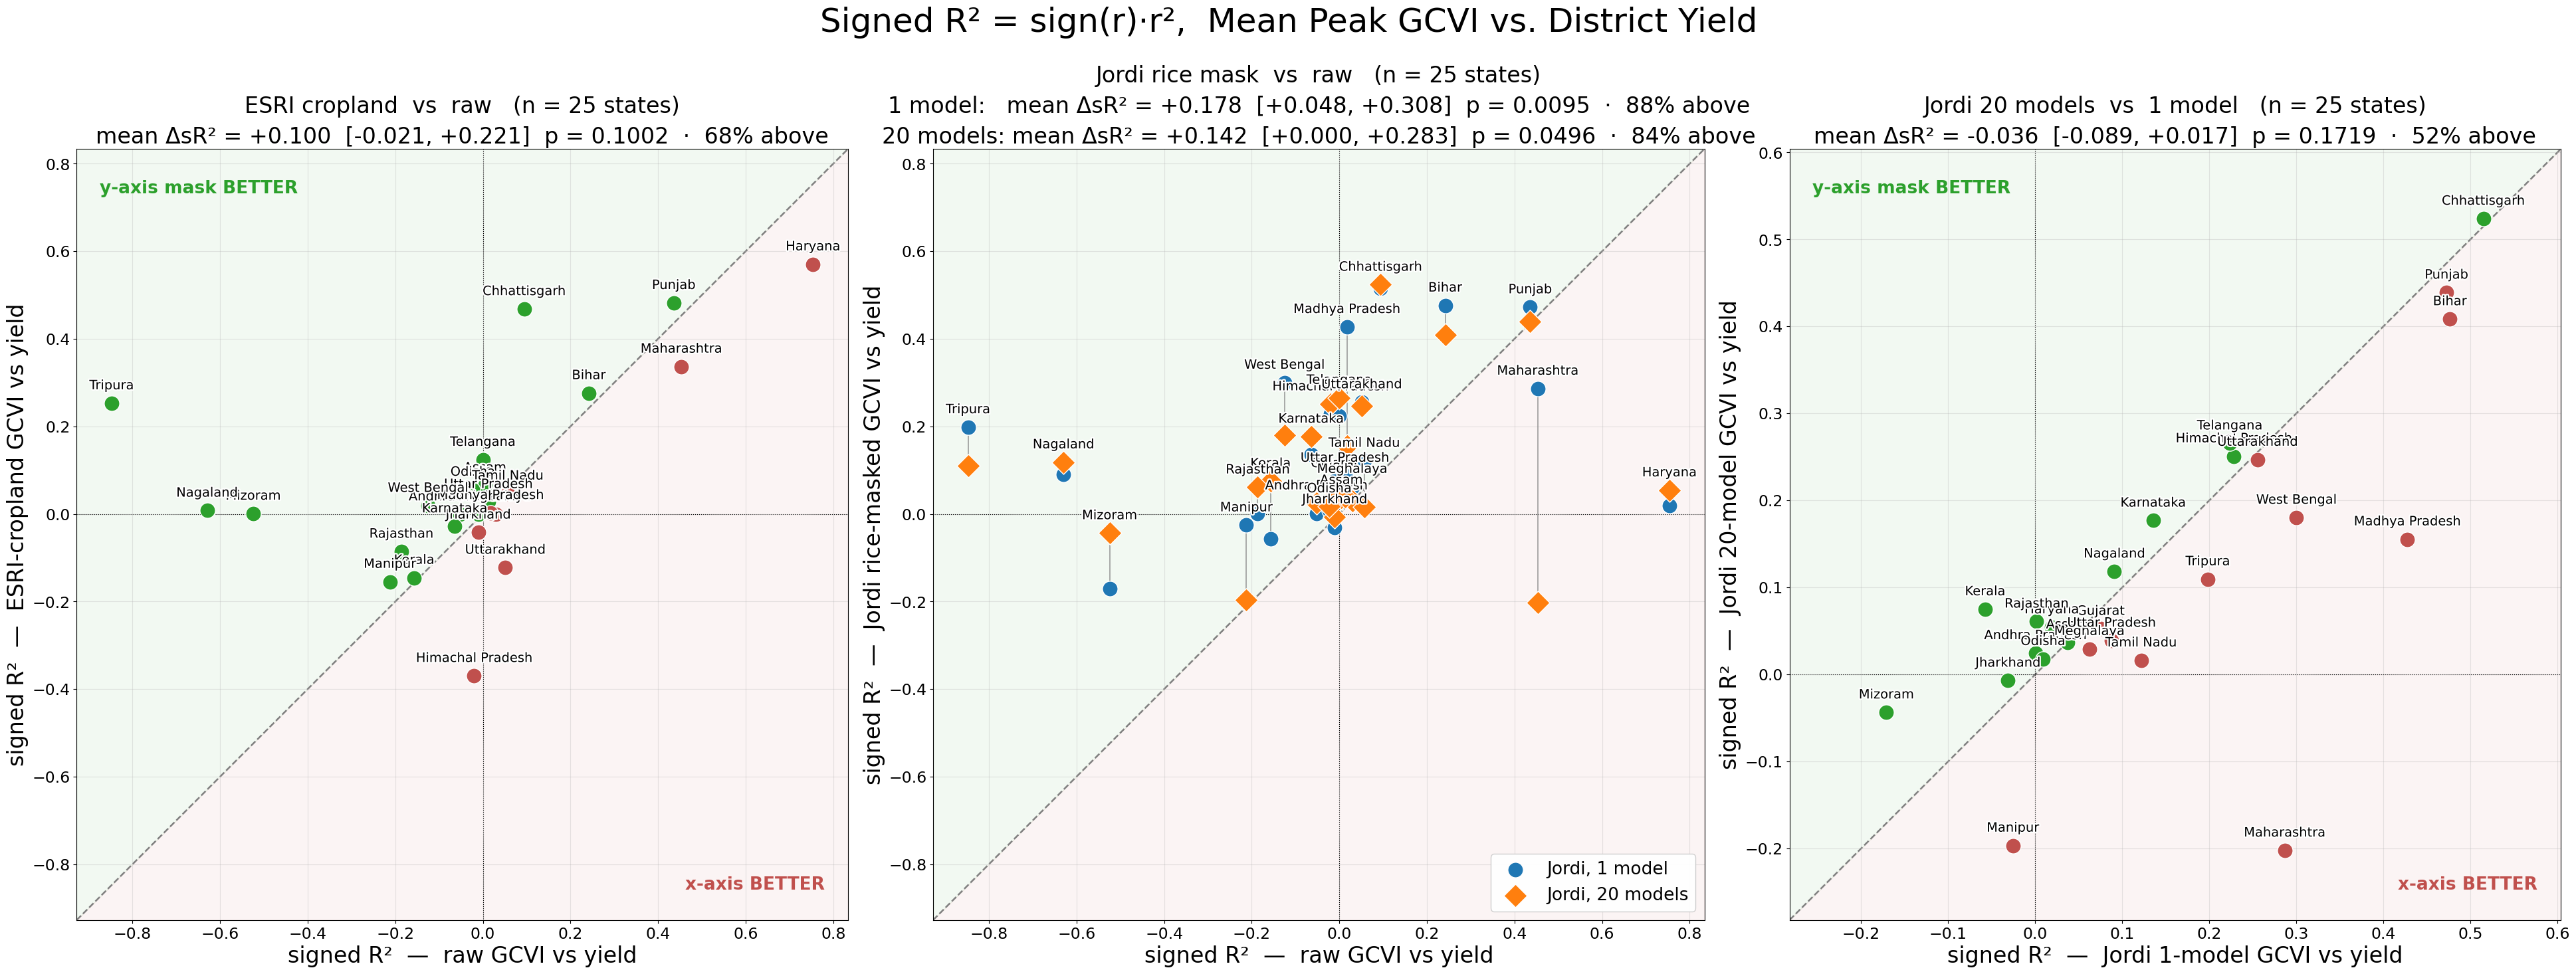

In [9]:
# same 1 x 3 layout as the r figure, in signed R²
def stat_line_R(v, tag=''):
    s = ttest(v)
    return (f"{tag}mean ΔsR² = {s['mean']:+.3f}  [{s['lo']:+.3f}, {s['hi']:+.3f}]  "
            f"p = {s['p']:.4f}  ·  {s['pos']:.0f}% above")

fig, axes = plt.subplots(1, 3, figsize=(39, 14.5))
SR_LAB = 'signed R²'

ax = axes[0]
d = T[['state', 'sR2_raw_300m', 'sR2_esri_300m']].dropna()
frame(ax, [d.sR2_raw_300m], [d.sR2_esri_300m])
up = d.sR2_esri_300m > d.sR2_raw_300m
ax.scatter(d.sR2_raw_300m[up],  d.sR2_esri_300m[up],  s=280, color='#2ca02c', ec='white', lw=1, zorder=3)
ax.scatter(d.sR2_raw_300m[~up], d.sR2_esri_300m[~up], s=280, color='#c0504d', ec='white', lw=1, zorder=3)
name_points(ax, d, 'sR2_raw_300m', 'sR2_esri_300m')
ax.set_xlabel(f'{SR_LAB}  —  raw GCVI vs yield', fontsize=24)
ax.set_ylabel(f'{SR_LAB}  —  ESRI-cropland GCVI vs yield', fontsize=24)
ax.set_title(f"ESRI cropland  vs  raw   (n = {len(d)} states)\n"
             f"{stat_line_R(d.sR2_esri_300m - d.sR2_raw_300m)}", fontsize=24, linespacing=1.5)

ax = axes[1]
d = T[['state', 'sR2_raw_300m', 'sR2_jordi_300m', 'sR2_jordi_300m_20models']].dropna()
frame(ax, [d.sR2_raw_300m], [d.sR2_jordi_300m, d.sR2_jordi_300m_20models])
for _, r in d.iterrows():
    ax.plot([r.sR2_raw_300m]*2, [r.sR2_jordi_300m, r.sR2_jordi_300m_20models],
            color='#888', lw=1.4, alpha=0.7, zorder=2)
ax.scatter(d.sR2_raw_300m, d.sR2_jordi_300m, s=280, marker='o', color='#1f77b4',
           ec='white', lw=1, zorder=3, label='Jordi, 1 model')
ax.scatter(d.sR2_raw_300m, d.sR2_jordi_300m_20models, s=320, marker='D', color='#ff7f0e',
           ec='white', lw=1, zorder=4, label='Jordi, 20 models')
d['_y'] = d[['sR2_jordi_300m', 'sR2_jordi_300m_20models']].max(axis=1)
name_points(ax, d, 'sR2_raw_300m', '_y')
ax.legend(loc='lower right', fontsize=19, framealpha=0.95)
ax.set_xlabel(f'{SR_LAB}  —  raw GCVI vs yield', fontsize=24)
ax.set_ylabel(f'{SR_LAB}  —  Jordi rice-masked GCVI vs yield', fontsize=24)
ax.set_title(f"Jordi rice mask  vs  raw   (n = {len(d)} states)\n"
             f"{stat_line_R(d.sR2_jordi_300m - d.sR2_raw_300m, '1 model:   ')}\n"
             f"{stat_line_R(d.sR2_jordi_300m_20models - d.sR2_raw_300m, '20 models: ')}",
             fontsize=24, linespacing=1.5)

ax = axes[2]
d = T[['state', 'sR2_jordi_300m', 'sR2_jordi_300m_20models']].dropna()
frame(ax, [d.sR2_jordi_300m], [d.sR2_jordi_300m_20models])
up = d.sR2_jordi_300m_20models > d.sR2_jordi_300m
ax.scatter(d.sR2_jordi_300m[up],  d.sR2_jordi_300m_20models[up],  s=280, color='#2ca02c', ec='white', lw=1, zorder=3)
ax.scatter(d.sR2_jordi_300m[~up], d.sR2_jordi_300m_20models[~up], s=280, color='#c0504d', ec='white', lw=1, zorder=3)
name_points(ax, d, 'sR2_jordi_300m', 'sR2_jordi_300m_20models')
ax.set_xlabel(f'{SR_LAB}  —  Jordi 1-model GCVI vs yield', fontsize=24)
ax.set_ylabel(f'{SR_LAB}  —  Jordi 20-model GCVI vs yield', fontsize=24)
ax.set_title(f"Jordi 20 models  vs  1 model   (n = {len(d)} states)\n"
             f"{stat_line_R(d.sR2_jordi_300m_20models - d.sR2_jordi_300m)}",
             fontsize=24, linespacing=1.5)

for ax in (axes[0], axes[2]):
    ax.text(0.03, 0.96, 'y-axis mask BETTER', transform=ax.transAxes, va='top',
            fontsize=19, color='#2ca02c', fontweight='bold')
    ax.text(0.97, 0.04, 'x-axis BETTER', transform=ax.transAxes, ha='right',
            fontsize=19, color='#c0504d', fontweight='bold')

fig.suptitle(f'Signed R² = sign(r)·r²,  Mean Peak GCVI vs. District Yield',
             y=1.02, fontsize=36)
plt.tight_layout()
plt.savefig(f'{OUT}/gcvi_2023_300m_scatter_signedR2.png', dpi=500, bbox_inches='tight')
plt.show()